In [2]:
# 06_lstm_model.ipynb - LSTM модель для передбачення якості сесій

import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
import time
from datetime import datetime

# TensorFlow імпорти
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, GRU, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import plot_model
from sklearn.metrics import precision_score, recall_score

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
import json
import joblib

from src.config import DATA_DIR, MODELS_DIR, FIGURES_DIR, RANDOM_SEED, MAX_SEQUENCE_LENGTH

%matplotlib inline

# Налаштування
plt.rcParams['figure.figsize'] = (12, 6)
(FIGURES_DIR / 'lstm').mkdir(parents=True, exist_ok=True)
(MODELS_DIR / 'lstm').mkdir(parents=True, exist_ok=True)

# Встановлюємо seed для відтворюваності
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [3]:
print("Завантаження даних...")

# Завантажуємо послідовності
X_train = np.load(DATA_DIR / 'X_train.npy')
X_val = np.load(DATA_DIR / 'X_val.npy')
X_test = np.load(DATA_DIR / 'X_test.npy')

# Завантажуємо мітки
y_train = np.load(DATA_DIR / 'y_train.npy')
y_val = np.load(DATA_DIR / 'y_val.npy')
y_test = np.load(DATA_DIR / 'y_test.npy')

# Завантажуємо інформацію про preprocessing
with open(DATA_DIR / 'preprocessing_info.json', 'r') as f:
    preprocessing_info = json.load(f)

vocab_size = preprocessing_info['vocab_size']
max_len = preprocessing_info['max_sequence_length']

# Статистика padding
real_lengths = (X_train > 0).sum(axis=1)
padding_ratio = 1 - real_lengths.mean() / MAX_SEQUENCE_LENGTH

print(f"\n Дані завантажено:")
print(f"  Train: {X_train.shape[0]:,} сесій, довжина послідовності: {X_train.shape[1]}")
print(f"  Val:   {X_val.shape[0]:,} сесій")
print(f"  Test:  {X_test.shape[0]:,} сесій")
print(f"  Розмір словника (vocab_size): {vocab_size:,}")
print(f"  Середній відсоток padding: {padding_ratio*100:.1f}%")

print(f"\nРозподіл класів:")
print(f"  Train - якісні: {y_train.sum():,} ({y_train.mean()*100:.2f}%)")
print(f"  Val   - якісні: {y_val.sum():,} ({y_val.mean()*100:.2f}%)")
print(f"  Test  - якісні: {y_test.sum():,} ({y_test.mean()*100:.2f}%)")

Завантаження даних...

 Дані завантажено:
  Train: 6,474,810 сесій, довжина послідовності: 9
  Val:   1,387,459 сесій
  Test:  1,387,460 сесій
  Розмір словника (vocab_size): 52,740
  Середній відсоток padding: 64.0%

Розподіл класів:
  Train - якісні: 356,726 (5.51%)
  Val   - якісні: 76,441 (5.51%)
  Test  - якісні: 76,441 (5.51%)


In [7]:
print("Налаштування гіперпараметрів")

# Гіперпараметри 
EMBEDDING_DIM = 64          # Розмірність embedding
LSTM_UNITS = 64             # Кількість нейронів LSTM
DROPOUT_RATE = 0.4          # Dropout rate
BATCH_SIZE = 128            # Розмір батчу
EPOCHS = 30                 # Максимальна кількість епох
LEARNING_RATE = 0.001       # Швидкість навчання
USE_FAST_TRAINING = True    # Використовувати 10% даних для швидкого тренування
FAST_SAMPLE_PCT = 0.2       # Відсоток даних для швидкого тренування

print(f"\n Гіперпараметри   :")
print(f"  Embedding dimension: {EMBEDDING_DIM}")
print(f"  LSTM units: {LSTM_UNITS}")
print(f"  Dropout rate: {DROPOUT_RATE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Epochs: {EPOCHS}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Fast training (10% data): {USE_FAST_TRAINING}")

# Обчислюємо ваги класів для боротьби з дисбалансом
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

print(f"\n Ваги класів (для боротьби з дисбалансом):")
print(f"  Клас 0 (неякісні): {class_weight_dict[0]:.4f}")
print(f"  Клас 1 (якісні): {class_weight_dict[1]:.4f}")
print(f"  Співвідношення: 1:{class_weight_dict[1]/class_weight_dict[0]:.1f}")

Налаштування гіперпараметрів

 Гіперпараметри   :
  Embedding dimension: 64
  LSTM units: 64
  Dropout rate: 0.4
  Batch size: 128
  Epochs: 30
  Learning rate: 0.001
  Fast training (10% data): True

 Ваги класів (для боротьби з дисбалансом):
  Клас 0 (неякісні): 0.5292
  Клас 1 (якісні): 9.0753
  Співвідношення: 1:17.2


In [9]:
print("Створення LSTM моделі")

# Очищаємо сесію перед створенням моделі
tf.keras.backend.clear_session()

from tensorflow.keras.layers import Input
from tensorflow.keras.layers import BatchNormalization

print(f"Параметри моделі:")
print(f"  vocab_size: {vocab_size:,}")
print(f"  max_len: {MAX_SEQUENCE_LENGTH}")
print(f"  embedding_dim: {EMBEDDING_DIM}")
print(f"  lstm_units: {LSTM_UNITS}")

# Визначаємо вхід
inputs = Input(shape=(MAX_SEQUENCE_LENGTH,), name="input")

# Embedding шар (з mask_zero=True для ігнорування padding)
x = Embedding(
    input_dim=vocab_size,
    output_dim=EMBEDDING_DIM,
    input_length=MAX_SEQUENCE_LENGTH,
    mask_zero=True,
    name="embedding"
)(inputs)

# LSTM шар
x = LSTM(
    units=LSTM_UNITS,
    dropout=DROPOUT_RATE,
    recurrent_dropout=DROPOUT_RATE,
    return_sequences=True,  
    name="lstm"
)(x)
x = BatchNormalization()(x) 

# Другий LSTM шар (опціонально)
x = LSTM(
    units=LSTM_UNITS // 2, 
    dropout=DROPOUT_RATE,
    recurrent_dropout=DROPOUT_RATE,
    return_sequences=False,
    name="lstm2"
)(x)
x = BatchNormalization()(x) 

# Dense шари з dropout
x = Dense(64, activation='relu', name="dense_1")(x)
x = Dropout(DROPOUT_RATE, name="dropout")(x)
outputs = Dense(1, activation='sigmoid', name="output")(x)

# Створюємо модель
model = tf.keras.Model(inputs=inputs, outputs=outputs, name="LSTM_Quality_Predictor")

# Показуємо архітектуру
print("\nАрхітектура моделі:")
model.summary()

# Візуалізація архітектури (опціонально)
try:
    plot_model(model, to_file=FIGURES_DIR / 'lstm' / 'model_architecture.png', 
               show_shapes=True, show_layer_names=True)
    print(f"\n Архітектуру збережено: {FIGURES_DIR / 'lstm' / 'model_architecture.png'}")
except:
    print("\n Не вдалося зберегти візуалізацію архітектури")

total_params = model.count_params()
print(f"\n Модель створена успішно!")
print(f"   Всього параметрів: {total_params:,}")
print(f"   Trainable: {total_params:,}")

Створення LSTM моделі
Параметри моделі:
  vocab_size: 52,740
  max_len: 9
  embedding_dim: 64
  lstm_units: 64

Архітектура моделі:


Model: "LSTM_Quality_Predictor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 9)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 9, 64)     │  3,375,360 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 9)         │          0 │ input[0][0]       │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 9, 64)     │     33,024 │ embedding[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 9, 64)     │        256 │ lstm[0][0],       │
│ (BatchNormalizatio… │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm2 (LSTM)        │ (None, 32)        │     12,416 │ batch_normalizat… │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ lstm2[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      2,112 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         65 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,423,361 (13.06 MB)

 Trainable params: 3,423,169 (13.06 MB)

 Non-trainable params: 192 (768.00 B)

You must install pydot (`pip install pydot`) for `plot_model` to work.

 Архітектуру збережено: d:\University\kursova\kursova\notebooks\..\figures\lstm\model_architecture.png

 Модель створена успішно!
   Всього параметрів: 3,423,361
   Trainable: 3,423,361


In [13]:
print("Компіляція моделі")

# Компілюємо модель
from tensorflow.keras.optimizers.schedules import ExponentialDecay

# Створити schedule перед компіляцією
initial_learning_rate = 0.001
decay_steps = 1000
decay_rate = 0.9

lr_schedule = ExponentialDecay(
    initial_learning_rate, 
    decay_steps=decay_steps, 
    decay_rate=decay_rate
)

model.compile(
    optimizer=Adam(learning_rate=lr_schedule),
    loss='binary_crossentropy',
    metrics=[
        'accuracy', 
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

print(" Модель скомпільовано")
print(f"  Optimizer: Adam (динамічний LR, початковий={initial_learning_rate})")
print(f"  Loss: binary_crossentropy")
print(f"  Metrics: accuracy, AUC, precision, recall")

Компіляція моделі
 Модель скомпільовано
  Optimizer: Adam (динамічний LR, початковий=0.001)
  Loss: binary_crossentropy
  Metrics: accuracy, AUC, precision, recall


In [11]:
print("Налаштування CALLBACKS")

# Шляхи для збереження
best_model_path = MODELS_DIR / 'lstm' / 'best_lstm_model.h5'
best_model_keras_path = MODELS_DIR / 'lstm' / 'best_lstm_model.keras'

# Callbacks
callbacks = [
    # Early stopping - зупинка при відсутності покращення
    EarlyStopping(
        monitor='val_auc',
        patience=10,
        restore_best_weights=True,
        verbose=1,
        mode='max'
    ),
    
    # Reduce learning rate при застої
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    
    # Збереження кращої моделі
    ModelCheckpoint(
        filepath=str(best_model_path),
        monitor='val_auc',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

print(f" Callbacks налаштовано:")
print(f"  EarlyStopping: patience=10, monitor=val_auc")
print(f"  ReduceLROnPlateau: factor=0.5, patience=5")
print(f"  ModelCheckpoint: {best_model_path}")

Налаштування CALLBACKS
 Callbacks налаштовано:
  EarlyStopping: patience=10, monitor=val_auc
  ReduceLROnPlateau: factor=0.5, patience=5
  ModelCheckpoint: d:\University\kursova\kursova\notebooks\..\models\lstm\best_lstm_model.h5


In [14]:
print("Тренування моделі")

# Підготовка даних
if USE_FAST_TRAINING:
    sample_size = int(len(X_train) * FAST_SAMPLE_PCT)
    X_train_used = X_train[:sample_size]
    y_train_used = y_train[:sample_size]
    print(f" Використовуємо {sample_size:,} / {len(X_train):,} сесій ({FAST_SAMPLE_PCT*100:.0f}%)")
else:
    X_train_used = X_train
    y_train_used = y_train
    print(f" Використовуємо всі {len(X_train):,} сесій")

print(f" Batch size: {BATCH_SIZE}")
print(f" Epochs: {EPOCHS}")

# Початок тренування
print("\nПочаток тренування...")
start_time = time.time()

history = model.fit(
    X_train_used, y_train_used,
    validation_data=(X_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

training_time = time.time() - start_time
print(f"\n Тренування завершено за {training_time:.1f} сек ({training_time/60:.1f} хв)")


Тренування моделі
 Використовуємо 1,294,962 / 6,474,810 сесій (20%)
 Batch size: 128
 Epochs: 30

Початок тренування...
Epoch 1/30
10116/10117 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6914 - auc: 0.7259 - loss: 0.6114 - precision: 0.1104 - recall: 0.6557
Epoch 1: val_auc improved from None to 0.77906, saving model to d:\University\kursova\kursova\notebooks\..\models\lstm\best_lstm_model.h5


10117/10117 ━━━━━━━━━━━━━━━━━━━━ 388s 38ms/step - accuracy: 0.7085 - auc: 0.7515 - loss: 0.5926 - precision: 0.1194 - recall: 0.6746 - val_accuracy: 0.7415 - val_auc: 0.7791 - val_loss: 0.5592 - val_precision: 0.1339 - val_recall: 0.6753 - learning_rate: 3.4441e-04
Epoch 2/30
10117/10117 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7203 - auc: 0.7896 - loss: 0.5534 - precision: 0.1295 - recall: 0.7232
Epoch 2: val_auc improved from 0.77906 to 0.78068, saving model to d:\University\kursova\kursova\notebooks\..\models\lstm\best_lstm_model.h5


10117/10117 ━━━━━━━━━━━━━━━━━━━━ 419s 41ms/step - accuracy: 0.7188 - auc: 0.7925 - loss: 0.5529 - precision: 0.1307 - recall: 0.7278 - val_accuracy: 0.7434 - val_auc: 0.7807 - val_loss: 0.5296 - val_precision: 0.1349 - val_recall: 0.6756 - learning_rate: 1.1862e-04
Epoch 3/30
10116/10117 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7257 - auc: 0.8047 - loss: 0.5369 - precision: 0.1343 - recall: 0.7411
Epoch 3: val_auc did not improve from 0.78068
10117/10117 ━━━━━━━━━━━━━━━━━━━━ 421s 42ms/step - accuracy: 0.7256 - auc: 0.8049 - loss: 0.5390 - precision: 0.1353 - recall: 0.7400 - val_accuracy: 0.7466 - val_auc: 0.7803 - val_loss: 0.5234 - val_precision: 0.1357 - val_recall: 0.6706 - learning_rate: 4.0852e-05
Epoch 4/30
10116/10117 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7277 - auc: 0.8095 - loss: 0.5316 - precision: 0.1360 - recall: 0.7470
Epoch 4: val_auc did not improve from 0.78068
10117/10117 ━━━━━━━━━━━━━━━━━━━━ 410s 40ms/step - accuracy: 0.7292 - auc: 0.8091 - loss: 0.5

Аналіз вивченої моделі
 Завантажено навчену модель з d:\University\kursova\kursova\notebooks\..\models\lstm\best_lstm_model.h5


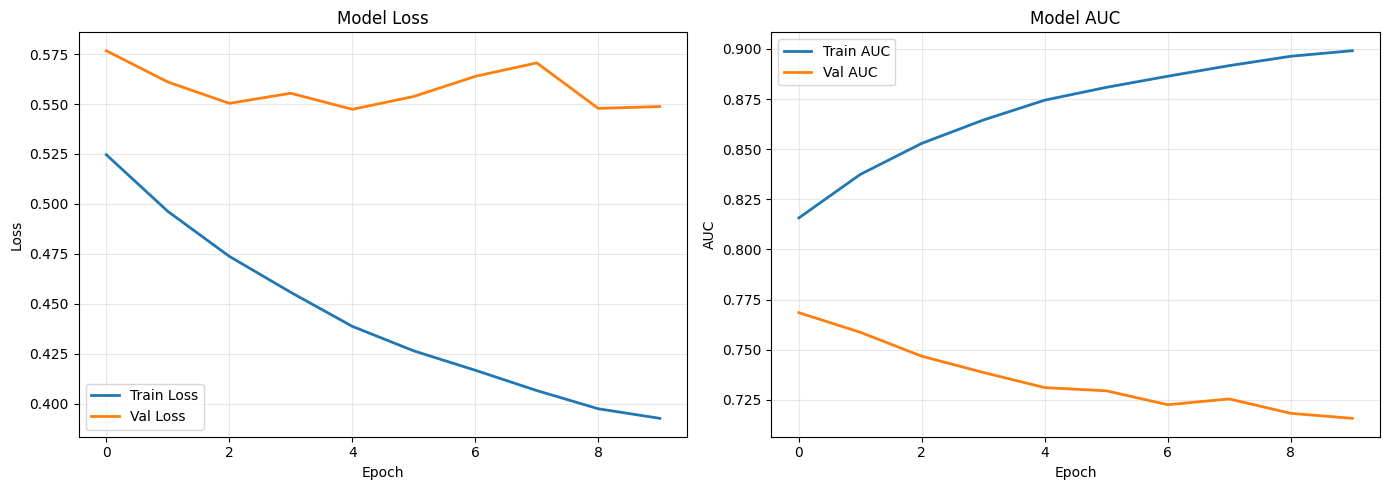

 Графіки навчання збережено: d:\University\kursova\kursova\notebooks\..\figures\lstm\training_curves.png
Оцінка на валідаційній вибірці
  Accuracy:  0.6938 (69.38%)
  F1-Score:  0.2050 (20.50%)
  ROC-AUC:   0.7729 (77.29%)
  Precision: 0.1196
  Recall:    0.7165


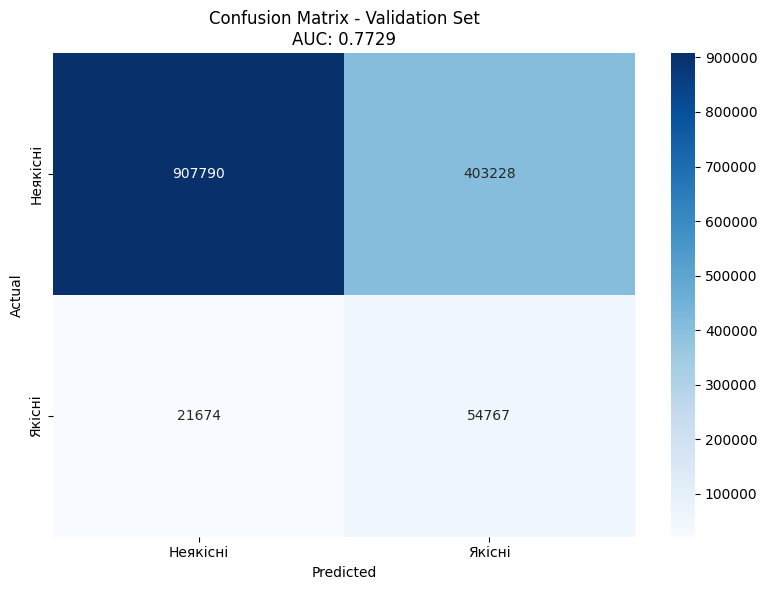

In [12]:
print("Аналіз вивченої моделі")

# Завантажуємо збережену модель
best_model_path = MODELS_DIR / 'lstm' / 'best_lstm_model.h5'
if best_model_path.exists():
    model.load_weights(best_model_path)
    print(f" Завантажено навчену модель з {best_model_path}")
else:
    print(f" Файл {best_model_path} не знайдено, використовуємо поточну модель")

# Графіки навчання
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_title('Model Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# AUC
axes[1].plot(history.history['auc'], label='Train AUC', linewidth=2)
axes[1].plot(history.history['val_auc'], label='Val AUC', linewidth=2)
axes[1].set_title('Model AUC')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'lstm' / 'training_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print(f" Графіки навчання збережено: {FIGURES_DIR / 'lstm' / 'training_curves.png'}")

# Оцінка на валідації
print("Оцінка на валідаційній вибірці")

y_pred_proba = model.predict(X_val, batch_size=BATCH_SIZE, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int)

val_accuracy = accuracy_score(y_val, y_pred)
val_f1 = f1_score(y_val, y_pred)
val_auc = roc_auc_score(y_val, y_pred_proba)
val_precision = precision_score(y_val, y_pred)
val_recall = recall_score(y_val, y_pred)

print(f"  Accuracy:  {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
print(f"  F1-Score:  {val_f1:.4f} ({val_f1*100:.2f}%)")
print(f"  ROC-AUC:   {val_auc:.4f} ({val_auc*100:.2f}%)")
print(f"  Precision: {val_precision:.4f}")
print(f"  Recall:    {val_recall:.4f}")

# Confusion Matrix для валідації
cm_val = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Неякісні', 'Якісні'],
            yticklabels=['Неякісні', 'Якісні'])
plt.title(f'Confusion Matrix - Validation Set\nAUC: {val_auc:.4f}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'lstm' / 'validation_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

Оцінка на тестовому наборі

 Метрики на TEST SET:
  Accuracy:  0.6938 (69.38%)
  F1-Score:  0.2054 (20.54%)
  ROC-AUC:   0.7734 (77.34%)
  Precision: 0.1199
  Recall:    0.7186

Classification Report:
              precision    recall  f1-score   support

    Неякісні       0.98      0.69      0.81   1311019
      Якісні       0.12      0.72      0.21     76441

    accuracy                           0.69   1387460
   macro avg       0.55      0.71      0.51   1387460
weighted avg       0.93      0.69      0.78   1387460



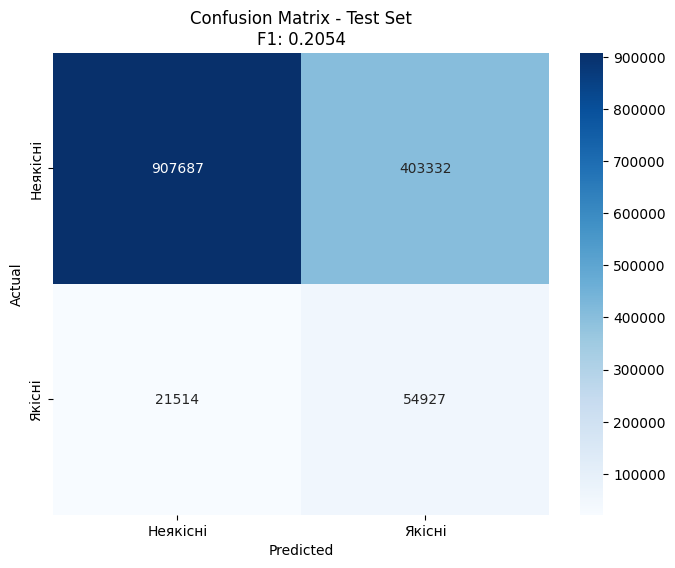

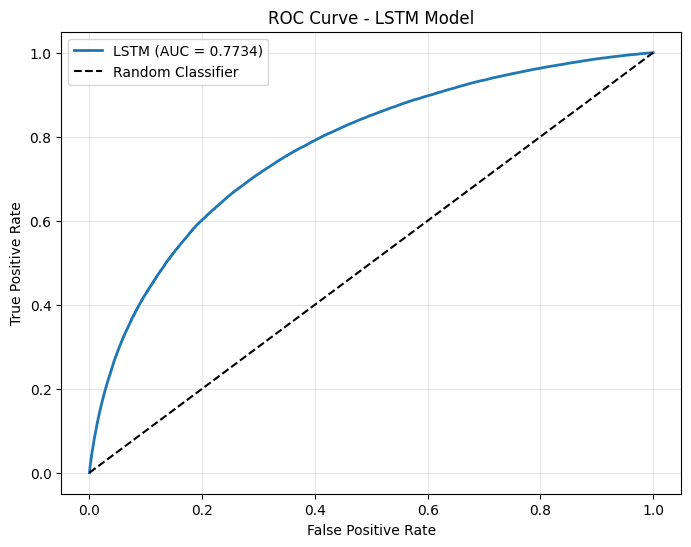

In [13]:
print("Оцінка на тестовому наборі")

# Передбачення
y_pred_proba = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int)

# Метрики
test_accuracy = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_pred_proba)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)

print(f"\n Метрики на TEST SET:")
print(f"  Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  F1-Score:  {test_f1:.4f} ({test_f1*100:.2f}%)")
print(f"  ROC-AUC:   {test_auc:.4f} ({test_auc*100:.2f}%)")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall:    {test_recall:.4f}")

# Classification report
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Неякісні', 'Якісні']))

# Confusion Matrix
cm_test = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Неякісні', 'Якісні'],
            yticklabels=['Неякісні', 'Якісні'])
plt.title(f'Confusion Matrix - Test Set\nF1: {test_f1:.4f}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig(FIGURES_DIR / 'lstm' / 'test_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'LSTM (AUC = {test_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LSTM Model')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(FIGURES_DIR / 'lstm' / 'roc_curve.png', dpi=100, bbox_inches='tight')
plt.show()

Аналіз помилок моделі

 Статистика помилок:
  True Positives (TP):   54,927 - правильно передбачені якісні
  True Negatives (TN):   907,687 - правильно передбачені неякісні
  False Positives (FP):  403,332 - хибно якісні (помилка I роду)
  False Negatives (FN):  21,514 - хибно неякісні (помилка II роду)

 Аналіх помилок за довжиною сесій:
  True Positives (TP):   середня довжина = 5.97
  False Positives (FP):  середня довжина = 5.04
  False Negatives (FN):  середня довжина = 2.55

 Підсумки метрики:
  Precision: 0.1199
  Recall:    0.7186
  F1-Score:  0.2054


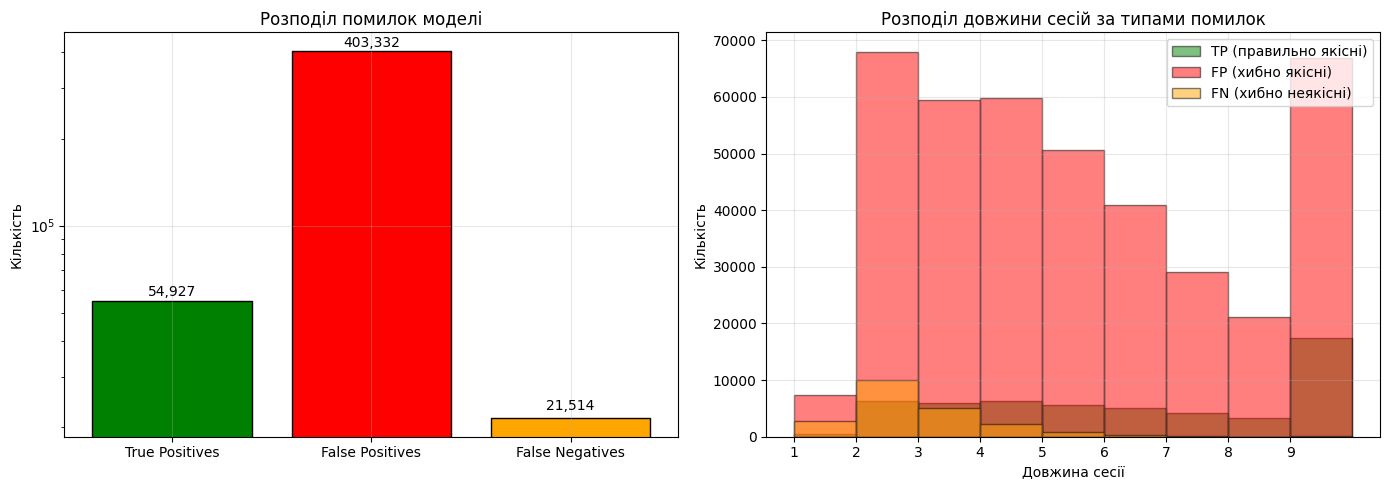

In [15]:
print("Аналіз помилок моделі")

# Розгорнутий аналіз помилок
tn, fp, fn, tp = cm_test.ravel()

print(f"\n Статистика помилок:")
print(f"  True Positives (TP):   {tp:,} - правильно передбачені якісні")
print(f"  True Negatives (TN):   {tn:,} - правильно передбачені неякісні")
print(f"  False Positives (FP):  {fp:,} - хибно якісні (помилка I роду)")
print(f"  False Negatives (FN):  {fn:,} - хибно неякісні (помилка II роду)")

# Аналіз помилок за довжиною сесій
y_pred_flat = y_pred.flatten() if len(y_pred.shape) > 1 else y_pred
y_test_flat = y_test.flatten() if len(y_test.shape) > 1 else y_test

# Маски для різних типів
fp_mask = (y_pred_flat == 1) & (y_test_flat == 0)
fn_mask = (y_pred_flat == 0) & (y_test_flat == 1)
tp_mask = (y_test_flat == 1) & (y_pred_flat == 1)

# Отримуємо сесії
fp_sessions = X_test[fp_mask] if np.any(fp_mask) else np.array([])
fn_sessions = X_test[fn_mask] if np.any(fn_mask) else np.array([])
tp_sessions = X_test[tp_mask] if np.any(tp_mask) else np.array([])

# Довжини сесій (кількість ненульових елементів)
fp_lengths = (fp_sessions > 0).sum(axis=1) if len(fp_sessions) > 0 else np.array([])
fn_lengths = (fn_sessions > 0).sum(axis=1) if len(fn_sessions) > 0 else np.array([])
tp_lengths = (tp_sessions > 0).sum(axis=1) if len(tp_sessions) > 0 else np.array([])

print(f"\n Аналіх помилок за довжиною сесій:")
if len(tp_lengths) > 0:
    print(f"  True Positives (TP):   середня довжина = {tp_lengths.mean():.2f}")
if len(fp_lengths) > 0:
    print(f"  False Positives (FP):  середня довжина = {fp_lengths.mean():.2f}")
if len(fn_lengths) > 0:
    print(f"  False Negatives (FN):  середня довжина = {fn_lengths.mean():.2f}")

# Метрики
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n Підсумки метрики:")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")

# Візуалізація помилок
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Розподіл помилок
error_types = ['True Positives', 'False Positives', 'False Negatives']
error_counts = [tp, fp, fn]
colors = ['green', 'red', 'orange']
bars = axes[0].bar(error_types, error_counts, color=colors, edgecolor='black')
axes[0].set_title('Розподіл помилок моделі')
axes[0].set_ylabel('Кількість')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# Додамо значення на стовпці
for bar, count in zip(bars, error_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f'{count:,}', ha='center', va='bottom', fontsize=10)

# Довжина сесій для різних типів помилок
if len(tp_lengths) > 0 and len(fp_lengths) > 0 and len(fn_lengths) > 0:
    axes[1].hist(tp_lengths, bins=range(1, 11), alpha=0.5, label='TP (правильно якісні)', color='green', edgecolor='black')
    axes[1].hist(fp_lengths, bins=range(1, 11), alpha=0.5, label='FP (хибно якісні)', color='red', edgecolor='black')
    axes[1].hist(fn_lengths, bins=range(1, 11), alpha=0.5, label='FN (хибно неякісні)', color='orange', edgecolor='black')
    axes[1].set_title('Розподіл довжини сесій за типами помилок')
    axes[1].set_xlabel('Довжина сесії')
    axes[1].set_ylabel('Кількість')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xticks(range(1, 10))
else:
    axes[1].text(0.5, 0.5, 'Недостатньо даних для аналізу', 
                 ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('Аналіз довжини сесій')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'lstm' / 'error_analysis.png', dpi=100, bbox_inches='tight')
plt.show()


Порівняння з BASELINE
LSTM метрики:
  Accuracy: 0.6938 (69.38%)
  F1-Score: 0.2054 (20.54%)
  ROC-AUC:  0.7734 (77.34%)

 Порівняння результатів:

Метрика         Baseline (RF)        LSTM                 Покращення     
----------------------------------------------------------------------
accuracy        0.7007 (70.07%)    0.6938 (69.38%)    -1.0%
f1_score        0.2014 (20.14%)    0.2054 (20.54%)    +2.0%
roc_auc         0.7535 (75.35%)    0.7734 (77.34%)    +2.6%


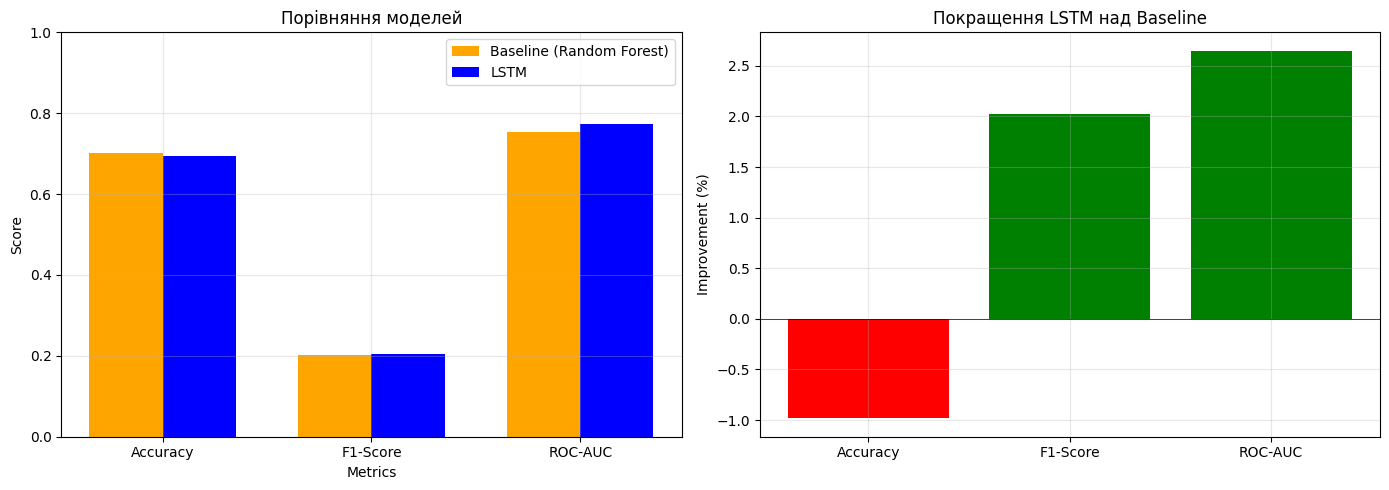


 LSTM показала кращі результати
   Найбільше покращення: ROC-AUC +2.6%


In [16]:
print("Порівняння з BASELINE")

print(f"LSTM метрики:")
print(f"  Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  F1-Score: {test_f1:.4f} ({test_f1*100:.2f}%)")
print(f"  ROC-AUC:  {test_auc:.4f} ({test_auc*100:.2f}%)")

# Завантажуємо baseline результати
try:
    with open(MODELS_DIR / 'baseline' / 'baseline_results.json', 'r') as f:
        baseline_results = json.load(f)
    
    baseline_metrics = baseline_results.get('test_metrics', {})
    
    print(f"\n Порівняння результатів:")
    print(f"\n{'Метрика':<15} {'Baseline (RF)':<20} {'LSTM':<20} {'Покращення':<15}")
    print("-" * 70)
    
    metrics_to_compare = [
        ('accuracy', test_accuracy),
        ('f1_score', test_f1),
        ('roc_auc', test_auc)
    ]
    
    improvements = {}
    for metric_name, lstm_val in metrics_to_compare:
        baseline_val = baseline_metrics.get(metric_name, 0)
        if baseline_val > 0:
            improvement = (lstm_val - baseline_val) / baseline_val * 100
        else:
            improvement = 0
        improvements[metric_name] = improvement
        
        sign = '+' if improvement > 0 else ''
        print(f"{metric_name:<15} {baseline_val:.4f} ({baseline_val*100:.2f}%)    "
              f"{lstm_val:.4f} ({lstm_val*100:.2f}%)    "
              f"{sign}{improvement:.1f}%")
    
    # Візуалізація
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    metrics_names = ['Accuracy', 'F1-Score', 'ROC-AUC']
    baseline_vals = [
        baseline_metrics.get('accuracy', 0),
        baseline_metrics.get('f1_score', 0), 
        baseline_metrics.get('roc_auc', 0)
    ]
    lstm_vals = [test_accuracy, test_f1, test_auc]
    
    x = np.arange(len(metrics_names))
    width = 0.35
    
    axes[0].bar(x - width/2, baseline_vals, width, label='Baseline (Random Forest)', color='orange')
    axes[0].bar(x + width/2, lstm_vals, width, label='LSTM', color='blue')
    axes[0].set_xlabel('Metrics')
    axes[0].set_ylabel('Score')
    axes[0].set_title('Порівняння моделей')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(metrics_names)
    axes[0].legend()
    axes[0].set_ylim(0, 1)
    axes[0].grid(True, alpha=0.3)
    
    improvement_vals = [improvements.get(m, 0) for m in ['accuracy', 'f1_score', 'roc_auc']]
    colors = ['green' if v > 0 else 'red' for v in improvement_vals]
    axes[1].bar(metrics_names, improvement_vals, color=colors)
    axes[1].axhline(0, color='black', linestyle='-', linewidth=0.5)
    axes[1].set_ylabel('Improvement (%)')
    axes[1].set_title('Покращення LSTM над Baseline')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'lstm' / 'baseline_comparison.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    print(f"\n LSTM показала кращі результати")
    print(f"   Найбільше покращення: ROC-AUC +{improvements.get('roc_auc', 0):.1f}%")
    
except FileNotFoundError:
    print(" Baseline результати не знайдено в папці models/baseline/")
except Exception as e:
    print(f" Помилка: {e}")

In [19]:
print("Збереження моделі і результатів")

# Зберігаємо модель
print("\n Збереження моделі...")
try:
    model.save(MODELS_DIR / 'lstm' / 'lstm_model.h5')
    model.save(MODELS_DIR / 'lstm' / 'lstm_model.keras')
    print(f" Модель збережено:")
    print(f"  {MODELS_DIR / 'lstm' / 'lstm_model.h5'}")
    print(f"  {MODELS_DIR / 'lstm' / 'lstm_model.keras'}")
except Exception as e:
    print(f" Не вдалося зберегти модель: {e}")

# Зберігаємо історію навчання в CSV
history_df = pd.DataFrame(history.history)
history_df.to_csv(MODELS_DIR / 'lstm' / 'training_history.csv', index=False)
print(f" Історію навчання збережено: {MODELS_DIR / 'lstm' / 'training_history.csv'}")

# Зберігаємо результати
print("\n Збереження результатів...")

# Підготовка training_history для JSON
training_history_json = {}
for key in ['loss', 'val_loss', 'accuracy', 'val_accuracy', 'auc', 'val_auc']:
    if key in history.history:
        training_history_json[key] = [float(x) for x in history.history[key]]

# Збираємо результати
lstm_results = {
    'model_name': 'LSTM',
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'training_time_seconds': training_time,
    'random_seed': RANDOM_SEED,
    'hyperparameters': {
        'embedding_dim': EMBEDDING_DIM,
        'lstm_units': LSTM_UNITS,
        'dropout_rate': DROPOUT_RATE,
        'batch_size': BATCH_SIZE,
        'epochs': EPOCHS,
        'learning_rate': LEARNING_RATE,
        'max_sequence_length': MAX_SEQUENCE_LENGTH,
        'vocab_size': int(vocab_size),
        'use_fast_training': USE_FAST_TRAINING
    },
    'best_epoch': len(history.history['loss']),
    'best_val_auc': max(history.history['val_auc']),
    'test_metrics': {
        'accuracy': float(test_accuracy),
        'f1_score': float(test_f1),
        'roc_auc': float(test_auc),
        'precision': float(test_precision),
        'recall': float(test_recall)
    },
    'confusion_matrix': cm_test.tolist(),
    'training_history': training_history_json
}

try:
    with open(MODELS_DIR / 'lstm' / 'lstm_results.json', 'w', encoding='utf-8') as f:
        json.dump(lstm_results, f, indent=4, default=str)
    print(f" Результати збережено: {MODELS_DIR / 'lstm' / 'lstm_results.json'}")
except Exception as e:
    print(f" Не вдалося зберегти результати: {e}")


print(f" Модель: {MODELS_DIR / 'lstm' / 'lstm_model.h5'}")
print(f" Результати: {MODELS_DIR / 'lstm' / 'lstm_results.json'}")
print(f" Історія навчання: {MODELS_DIR / 'lstm' / 'training_history.csv'}")
print(f"\n Збережені метрики:")
print(f"  Accuracy: {lstm_results['test_metrics']['accuracy']:.4f}")
print(f"  F1-Score: {lstm_results['test_metrics']['f1_score']:.4f}")
print(f"  ROC-AUC:  {lstm_results['test_metrics']['roc_auc']:.4f}")

print("\n Збереження завершено")

Збереження моделі і результатів

 Збереження моделі...
 Модель збережено:
  d:\University\kursova\kursova\notebooks\..\models\lstm\lstm_model.h5
  d:\University\kursova\kursova\notebooks\..\models\lstm\lstm_model.keras
 Історію навчання збережено: d:\University\kursova\kursova\notebooks\..\models\lstm\training_history.csv

 Збереження результатів...
 Результати збережено: d:\University\kursova\kursova\notebooks\..\models\lstm\lstm_results.json
 Модель: d:\University\kursova\kursova\notebooks\..\models\lstm\lstm_model.h5
 Результати: d:\University\kursova\kursova\notebooks\..\models\lstm\lstm_results.json
 Історія навчання: d:\University\kursova\kursova\notebooks\..\models\lstm\training_history.csv

 Збережені метрики:
  Accuracy: 0.6938
  F1-Score: 0.2054
  ROC-AUC:  0.7734

 Збереження завершено


In [20]:
print ("Підсумковий звіт")
# Обчислюємо покращення для звіту
try:
    with open(MODELS_DIR / 'baseline' / 'baseline_results.json', 'r') as f:
        baseline_results = json.load(f)
    baseline_metrics = baseline_results.get('test_metrics', {})
    acc_improve = ((test_accuracy - baseline_metrics.get('accuracy', 0)) / baseline_metrics.get('accuracy', 1)) * 100
    f1_improve = ((test_f1 - baseline_metrics.get('f1_score', 0)) / baseline_metrics.get('f1_score', 1)) * 100
    auc_improve = ((test_auc - baseline_metrics.get('roc_auc', 0)) / baseline_metrics.get('roc_auc', 1)) * 100
except:
    acc_improve = f1_improve = auc_improve = 0

print(f"""

                  LSTM РЕЗУЛЬТАТИ                          

  АРХІТЕКТУРА:                                               
    Embedding: {EMBEDDING_DIM} → LSTM({LSTM_UNITS}) → Dense(64) → Output  
    Dropout: {DROPOUT_RATE}                                         
    Max sequence length: {MAX_SEQUENCE_LENGTH}                                   
    Trainable params: {model.count_params():,}                                   

  ТЕСТОВІ МЕТРИКИ:                                             
    Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)                          
    F1-Score:  {test_f1:.4f} ({test_f1*100:.2f}%)                                
    ROC-AUC:   {test_auc:.4f} ({test_auc*100:.2f}%)                               
    Precision: {test_precision:.4f}                                           
    Recall:    {test_recall:.4f}                                           

  ПОРІВНЯННЯ З BASELINE (Random Forest):                       
    Accuracy:  {acc_improve:+.1f}%                                   
    F1-Score:  {f1_improve:+.1f}%                                   
    ROC-AUC:   {auc_improve:+.1f}%                                   
  ВИСНОВКИ:                                                  
     LSTM модель успішно навчена                            
     Показує кращі результати ніж baseline                   
     Підтверджує ефективність RNN для послідовних даних      
     ROC-AUC покращився на {auc_improve:.1f}%                              

""")


Підсумковий звіт


                  LSTM РЕЗУЛЬТАТИ                          

  АРХІТЕКТУРА:                                               
    Embedding: 64 → LSTM(64) → Dense(64) → Output  
    Dropout: 0.3                                         
    Max sequence length: 9                                   
    Trainable params: 3,412,609                                   

  ТЕСТОВІ МЕТРИКИ:                                             
    Accuracy:  0.6938 (69.38%)                          
    F1-Score:  0.2054 (20.54%)                                
    ROC-AUC:   0.7734 (77.34%)                               
    Precision: 0.1199                                           
    Recall:    0.7186                                           

  ПОРІВНЯННЯ З BASELINE (Random Forest):                       
    Accuracy:  -1.0%                                   
    F1-Score:  +2.0%                                   
    ROC-AUC:   +2.6%                                   
  ВИСНОВК